# Reconnaissance du genre

In [1]:
#%pip install matplotlib
#%pip install seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression

## 1. Chargement et exploration des données

In [2]:
df = pd.read_csv("BoW_1000_personnages.csv")

In [3]:
df.head()

,title,Gender,author_gender,type,avoir,dire,voir,faire,vouloir,pouvoir,...,lunette,gens,façon,propre,ménage,manteau,troupe,futur,daigner,geste
0,1833_Girardin-Delphine-de_Contes-d-une-vieille...,0,0,1,0.031686,0.021546,0.024081,0.017744,0.031686,0.027883,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1833_Girardin-Delphine-de_Contes-d-une-vieille...,1,1,1,0.020779,0.020779,0.036364,0.015584,0.024675,0.024675,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1833_Girardin-Delphine-de_Contes-d-une-vieille...,0,1,1,0.026415,0.011321,0.015094,0.011321,0.020755,0.024528,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1833_Girardin-Delphine-de_Contes-d-une-vieille...,1,1,1,0.018908,0.023109,0.025210,0.012605,0.018908,0.016807,...,0.002101,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1833_Girardin-Delphine-de_Contes-d-une-vieille...,0,1,2,0.025822,0.016432,0.016432,0.032864,0.009390,0.009390,...,0.000000,0.002347,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# suppression de la colonne des titres et des celles du genre
df.drop(columns=["title", "type","author_gender"], axis=1, inplace=True)

In [5]:
df.head()

,Gender,avoir,dire,voir,faire,vouloir,pouvoir,aller,petit,savoir,...,lunette,gens,façon,propre,ménage,manteau,troupe,futur,daigner,geste
0,0,0.031686,0.021546,0.024081,0.017744,0.031686,0.027883,0.015209,0.002535,0.020279,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,0.020779,0.020779,0.036364,0.015584,0.024675,0.024675,0.010390,0.020779,0.009091,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0.026415,0.011321,0.015094,0.011321,0.020755,0.024528,0.013208,0.011321,0.018868,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,0.018908,0.023109,0.025210,0.012605,0.018908,0.016807,0.025210,0.018908,0.006303,...,0.002101,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0.025822,0.016432,0.016432,0.032864,0.009390,0.009390,0.014085,0.011737,0.009390,...,0.000000,0.002347,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
# affichage du nombre d'occurrences de chaque type de personnage
# 0 = adult, 1= enfant, 2= animal, 3 = pupée, 4 = object, 5 = other
df["Gender"].value_counts()

Gender
0    353
1    260
Name: count, dtype: int64

## 2. Entraînement SVC

In [8]:
# séparation des features et de la target
X = df.drop(columns=["Gender"])
Y = df["Gender"]

In [9]:
X.head()

,avoir,dire,voir,faire,vouloir,pouvoir,aller,petit,savoir,aimer,...,lunette,gens,façon,propre,ménage,manteau,troupe,futur,daigner,geste
0,0.031686,0.021546,0.024081,0.017744,0.031686,0.027883,0.015209,0.002535,0.020279,0.019011,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.020779,0.020779,0.036364,0.015584,0.024675,0.024675,0.010390,0.020779,0.009091,0.009091,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.026415,0.011321,0.015094,0.011321,0.020755,0.024528,0.013208,0.011321,0.018868,0.007547,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.018908,0.023109,0.025210,0.012605,0.018908,0.016807,0.025210,0.018908,0.006303,0.018908,...,0.002101,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.025822,0.016432,0.016432,0.032864,0.009390,0.009390,0.014085,0.011737,0.009390,0.009390,...,0.000000,0.002347,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
Y.head()

0    0
1    1
2    0
3    1
4    0
Name: Gender, dtype: int64

Accuratezza media: 0.843


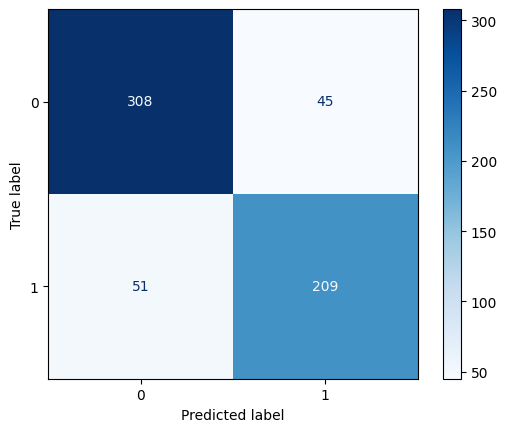

In [15]:
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Creazione della Pipeline: prima scala i dati, poi applica SVM
clf_pipeline = make_pipeline(StandardScaler(), svm.SVC(kernel='sigmoid', C=1.0))

# 1. Calcolo dell'accuratezza media
scores = cross_val_score(clf_pipeline, X, Y, cv=5, n_jobs=-1) # n_jobs=-1 usa tutti i core
print(f"Accuratezza media: {scores.mean():.3f}")

# 2. Ottenere predizioni per la Matrice di Confusione
Y_pred = cross_val_predict(clf_pipeline, X, Y, cv=5, n_jobs=-1)
cm = confusion_matrix(Y,Y_pred)

# Visualizzazione
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

## Permutation Feature Importance

Idea:

- Mischi una feature alla volta
- misuri quanto crolla l’accuracy
- più crolla → più la feature è importante

In [16]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
import pandas as pd

# Dividiamo in train e test per velocizzare l'importanza (calcolarla su tutto il dataset è lento)
X_train, X_val, y_train, y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

# Addestriamo il modello sul set di train
clf_pipeline.fit(X_train, y_train)

# Calcolo importanza (Ottimizzato)
result = permutation_importance(
    clf_pipeline, X_val, y_val, 
    n_repeats=3,         # Ridotto per velocità
    random_state=42, 
    n_jobs=-1            # Parallelizzazione massimizzata
)

# Organizziamo i risultati in un DataFrame per visualizzare le top 20
feature_importance = pd.Series(result.importances_mean, index=X.columns)
print("Top 10 Feature Importanti:")
print(feature_importance.sort_values(ascending=False).head(10))

Top 10 Feature Importanti:
mari          0.01897
consentir     0.01897
main          0.01626
toilette      0.01626
frapper       0.01626
teint         0.01355
enfant        0.01355
surprise      0.01355
souffrance    0.01355
robe          0.01355
dtype: float64


/var/folders/dy/_vzc_bl12fv1jxcs5db4wmwh0000gn/T/ipykernel_15266/4147637179.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


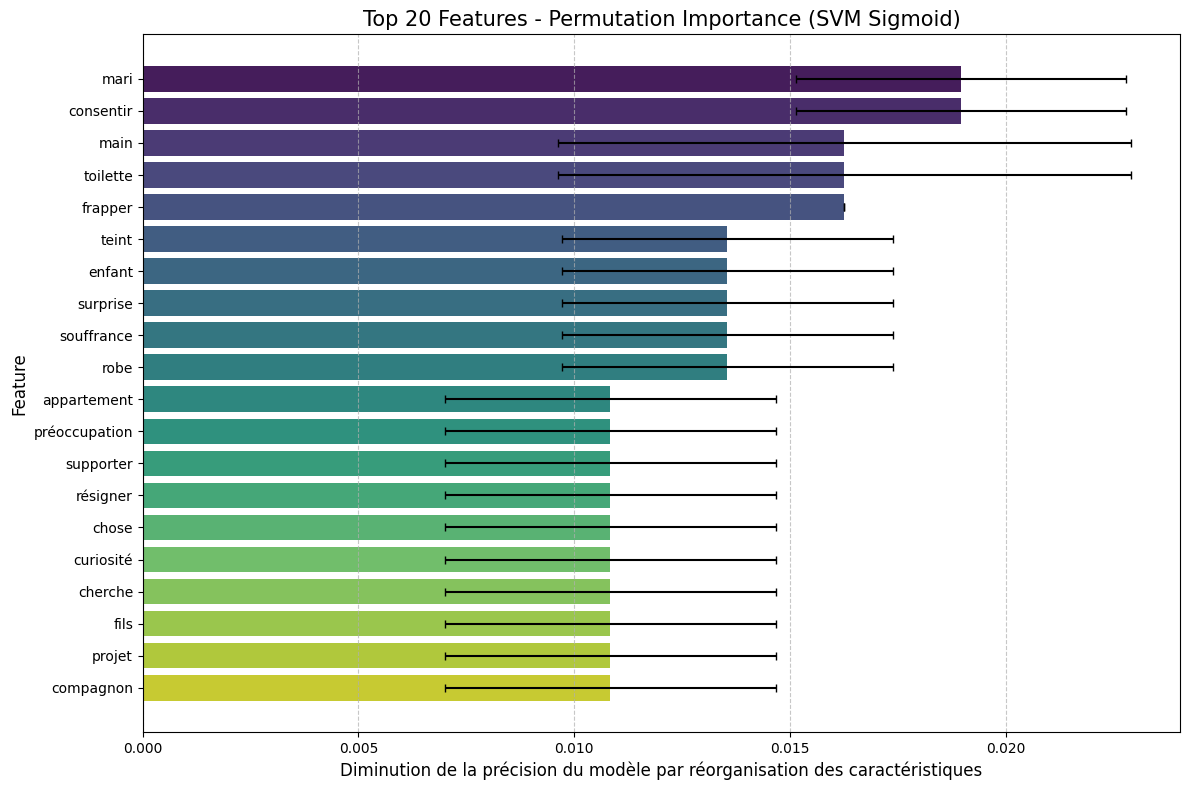

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Creiamo un DataFrame con i risultati per facilitare il plotting
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean,
    'Std_Dev': result.importances_std
}).sort_values(by='Importance', ascending=False)

# 2. Selezioniamo solo le top 20 feature
top_n = 20
top_importance = importance_df.head(top_n)

# 3. Creazione del grafico
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=top_importance, 
    palette='viridis'
)

# Aggiungiamo le barre di errore (deviazione standard tra i repeat)
plt.errorbar(
    x=top_importance['Importance'], 
    y=range(top_n), 
    xerr=top_importance['Std_Dev'], 
    fmt='none', 
    c='black', 
    capsize=3
)

plt.title(f'Top {top_n} Features - Permutation Importance (SVM Sigmoid)', fontsize=15)
plt.xlabel('Diminution de la précision du modèle par réorganisation des caractéristiques', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 3. Random Forest

Accuratezza media (Random Forest): 0.858


,steps,"[('standardscaler', ...), ('randomforestclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2


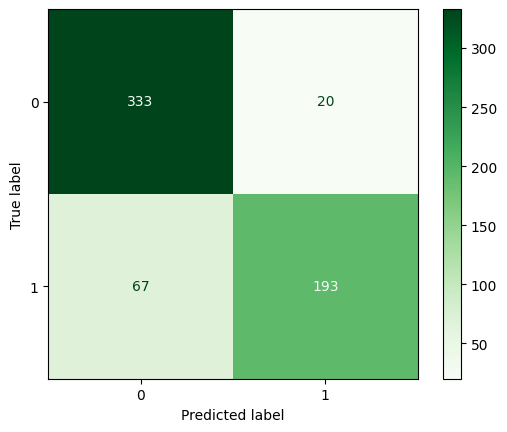

In [ ]:
from sklearn.ensemble import RandomForestClassifier # Cambiato qui
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. Creazione della Pipeline
# Nota: RandomForest non richiede scaling, ma lo teniamo per coerenza con la tua struttura
clf_pipeline = make_pipeline(
    StandardScaler(), 
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
)

# 2. Calcolo dell'accuratezza media con Cross-Validation
scores = cross_val_score(clf_pipeline, X, Y, cv=5, n_jobs=-1)
print(f"Accuratezza media (Random Forest): {scores.mean():.3f}")

# 3. Ottenere predizioni per la Matrice di Confusione
Y_pred = cross_val_predict(clf_pipeline, X, Y, cv=5, n_jobs=-1)
cm = confusion_matrix(Y, Y_pred)

# Visualizzazione Matrice di Confusione
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Greens') # Cambiato colore in verde, tipico dei Forest
# --- Analisi dell'Importanza delle Feature ---

# Suddivisione Train/Validation
X_train, X_val, y_train, y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

# Addestramento
clf_pipeline.fit(X_train, y_train)


Top 10 Feature Importanti (Random Forest):
mari        0.045528
fille       0.022764
soin        0.016260
petit       0.014634
toilette    0.013008
robe        0.011382
ami         0.011382
amie        0.009756
voisin      0.008130
tarder      0.008130
dtype: float64


/var/folders/dy/_vzc_bl12fv1jxcs5db4wmwh0000gn/T/ipykernel_15266/2997729635.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


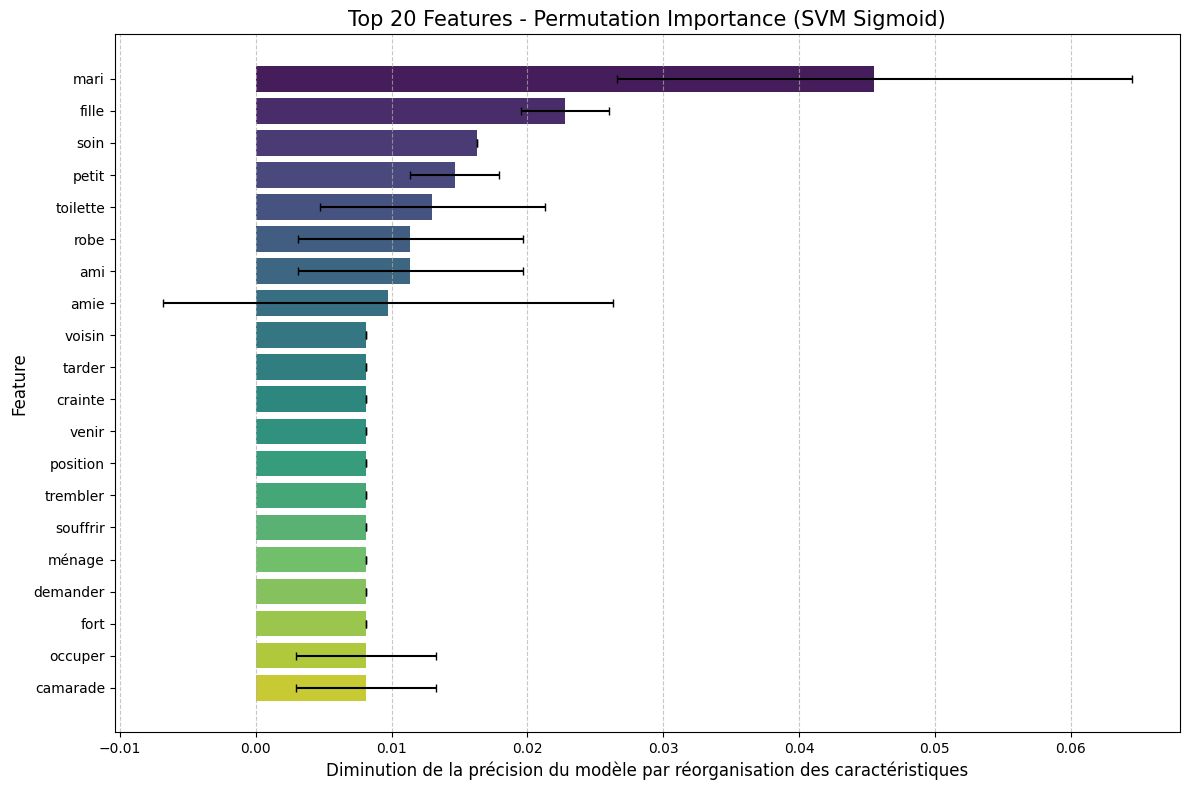

In [ ]:
# Calcolo Permutation Importance
result = permutation_importance(
    clf_pipeline, X_val, y_val, 
    n_repeats=5,         
    random_state=42, 
    n_jobs=-1            
)

# Visualizzazione Risultati
feature_importance = pd.Series(result.importances_mean, index=X.columns)
print("\nTop 10 Feature Importanti (Random Forest):")
print(feature_importance.sort_values(ascending=False).head(10))
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Creiamo un DataFrame con i risultati per facilitare il plotting
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean,
    'Std_Dev': result.importances_std
}).sort_values(by='Importance', ascending=False)

# 2. Selezioniamo solo le top 20 feature
top_n = 20
top_importance = importance_df.head(top_n)

# 3. Creazione del grafico
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=top_importance, 
    palette='viridis'
)

# Aggiungiamo le barre di errore (deviazione standard tra i repeat)
plt.errorbar(
    x=top_importance['Importance'], 
    y=range(top_n), 
    xerr=top_importance['Std_Dev'], 
    fmt='none', 
    c='black', 
    capsize=3
)

plt.title(f'Top {top_n} Features - Permutation Importance (SVM Sigmoid)', fontsize=15)
plt.xlabel('Diminution de la précision du modèle par réorganisation des caractéristiques', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Logistic regression

Accuratezza media (Logistic Regression): 0.853

Top 10 Feature Importanti (Logistic Regression):
toilette       0.021138
robe           0.019512
maison         0.019512
appartement    0.017886
fils           0.017886
mari           0.017886
passer         0.016260
étonnement     0.016260
dieu           0.016260
air            0.014634
dtype: float64


/var/folders/dy/_vzc_bl12fv1jxcs5db4wmwh0000gn/T/ipykernel_15266/319846390.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


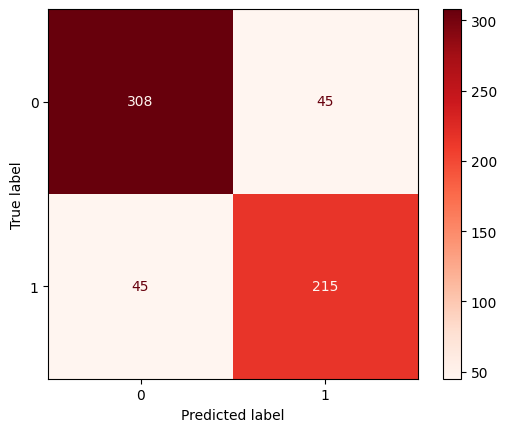

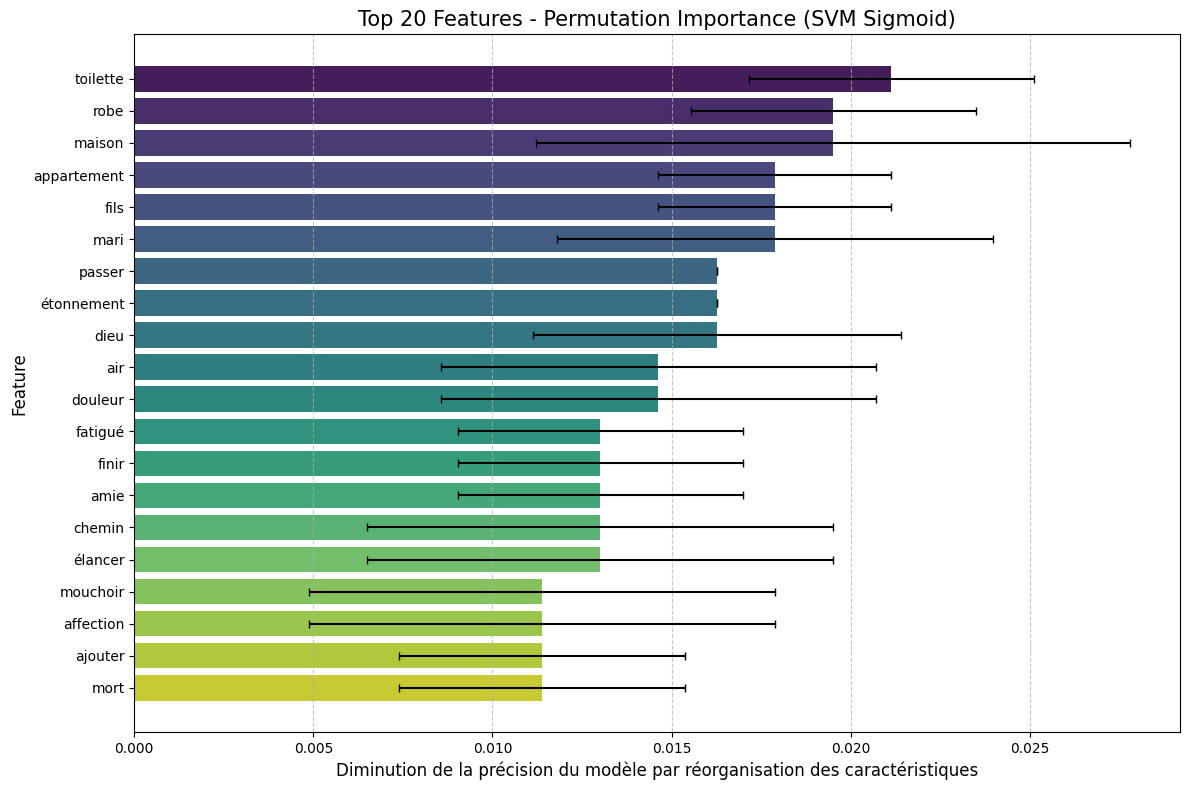

Parole più 'femminili' (Coefficienti positivi):
           word  coefficient
76         amie     0.424149
113        dieu     0.422301
230        robe     0.385015
341       chéri     0.338612
95         mari     0.334149
41        fille     0.297693
87          mme     0.290751
33         oeil     0.288412
268        joli     0.286007
309  grand'mère     0.273838

Parole più 'maschili' (Coefficienti negativi):
            word  coefficient
195        homme    -0.266360
507      mauvais    -0.267533
25           ami    -0.268172
3          faire    -0.270714
622      honnête    -0.283117
377        habit    -0.300684
430  recommander    -0.305599
57            m.    -0.314319
212        jambe    -0.369702
154     camarade    -0.373377


In [22]:

from sklearn.linear_model import LogisticRegression # Import specifico
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. Creazione della Pipeline
# Per la Logistic Regression, lo StandardScaler è CRUCIALE per la convergenza
clf_pipeline = make_pipeline(
    StandardScaler(), 
    LogisticRegression(max_iter=1000, random_state=42)
)

# 2. Calcolo dell'accuratezza media
scores = cross_val_score(clf_pipeline, X, Y, cv=5, n_jobs=-1)
print(f"Accuratezza media (Logistic Regression): {scores.mean():.3f}")

# 3. Matrice di Confusione
Y_pred = cross_val_predict(clf_pipeline, X, Y, cv=5, n_jobs=-1)
cm = confusion_matrix(Y, Y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Reds') # Colore rosso per distinguere il modello lineare

# --- Analisi dell'Importanza delle Feature ---
X_train, X_val, y_train, y_val = train_test_split(X, Y, test_size=0.2, random_state=42)
clf_pipeline.fit(X_train, y_train)

# Calcolo Permutation Importance
result = permutation_importance(
    clf_pipeline, X_val, y_val, 
    n_repeats=5,         
    random_state=42, 
    n_jobs=-1            
)

feature_importance = pd.Series(result.importances_mean, index=X.columns)
print("\nTop 10 Feature Importanti (Logistic Regression):")
print(feature_importance.sort_values(ascending=False).head(10))
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Creiamo un DataFrame con i risultati per facilitare il plotting
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean,
    'Std_Dev': result.importances_std
}).sort_values(by='Importance', ascending=False)

# 2. Selezioniamo solo le top 20 feature
top_n = 20
top_importance = importance_df.head(top_n)

# 3. Creazione del grafico
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=top_importance, 
    palette='viridis'
)

# Aggiungiamo le barre di errore (deviazione standard tra i repeat)
plt.errorbar(
    x=top_importance['Importance'], 
    y=range(top_n), 
    xerr=top_importance['Std_Dev'], 
    fmt='none', 
    c='black', 
    capsize=3
)

plt.title(f'Top {top_n} Features - Permutation Importance (SVM Sigmoid)', fontsize=15)
plt.xlabel('Diminution de la précision du modèle par réorganisation des caractéristiques', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# Dopo aver addestrato la pipeline della Logistic Regression
model = clf_pipeline.named_steps['logisticregression']
features = X.columns

# Estraiamo i pesi
weights = pd.DataFrame({'word': features, 'coefficient': model.coef_[0]})
weights = weights.sort_values(by='coefficient', ascending=False)

print("Parole più 'femminili' (Coefficienti positivi):")
print(weights.head(10))

print("\nParole più 'maschili' (Coefficienti negativi):")
print(weights.tail(10))